SVM Kernels Indepth Intution And Practical Explanation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-0.5,5.0,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [2]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

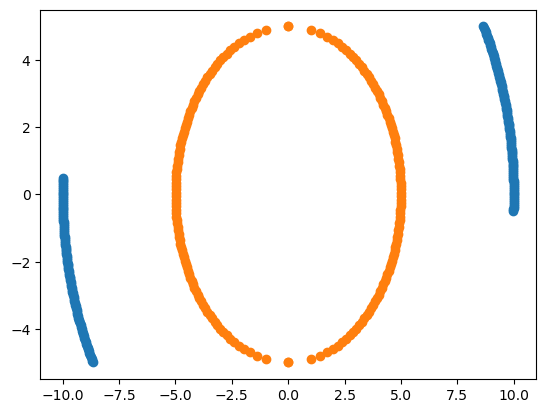

In [3]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [6]:
np.vstack([y,x]).T

array([[  9.98749218,  -0.5       ],
       [  9.99011857,  -0.44444444],
       [  9.99243541,  -0.38888889],
       [  9.9944429 ,  -0.33333333],
       [  9.99614123,  -0.27777778],
       [  9.99753056,  -0.22222222],
       [  9.99861101,  -0.16666667],
       [  9.9993827 ,  -0.11111111],
       [  9.99984568,  -0.05555556],
       [ 10.        ,   0.        ],
       [  9.99984568,   0.05555556],
       [  9.9993827 ,   0.11111111],
       [  9.99861101,   0.16666667],
       [  9.99753056,   0.22222222],
       [  9.99614123,   0.27777778],
       [  9.9944429 ,   0.33333333],
       [  9.99243541,   0.38888889],
       [  9.99011857,   0.44444444],
       [  9.98749218,   0.5       ],
       [  9.98455598,   0.55555556],
       [  9.98130969,   0.61111111],
       [  9.97775303,   0.66666667],
       [  9.97388566,   0.72222222],
       [  9.9697072 ,   0.77777778],
       [  9.96521729,   0.83333333],
       [  9.96041548,   0.88888889],
       [  9.95530134,   0.94444444],
 

In [7]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['x1','x2'])
df1['y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df2['y']=1
# df=df1.append(df2)
# Correct way: use concat
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,x1,x2,y
0,9.987492,-0.500000,0
1,9.990119,-0.444444,0
2,9.992435,-0.388889,0
3,9.994443,-0.333333,0
4,9.996141,-0.277778,0


In [8]:
df.tail()

,x1,x2,y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [9]:
### Independent and Dependent features
x = df.iloc[:,:2]
y = df.y

In [10]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: y, Length: 400, dtype: int64

In [12]:
## SPlit the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=10)

In [13]:
y_train

57     0
87     0
357    1
355    1
238    1
      ..
369    1
320    1
15     0
125    0
265    1
Name: y, Length: 300, dtype: int64

In [14]:
## We need to find components for the polynomial kernel
#x1,x2,x1_square,x2_square,x1*x2
df['x1_Square']=df['x1']**2
df['x2_Square']=df['x2']**2
df['x1*x2'] = (df['x1']*df['x2'])
df.head()

,x1,x2,y,x1_Square,x2_Square,x1*x2
0,9.987492,-0.500000,0,99.750000,0.250000,-4.993746
1,9.990119,-0.444444,0,99.802469,0.197531,-4.440053
2,9.992435,-0.388889,0,99.848765,0.151235,-3.885947
3,9.994443,-0.333333,0,99.888889,0.111111,-3.331481
4,9.996141,-0.277778,0,99.922840,0.077160,-2.776706


In [15]:
## Independent and dependent feature
x = df[['x1','x2','x1_Square','x2_Square','x1*x2']]
y = df['y']

In [16]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: y, Length: 400, dtype: int64

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [18]:
x_train

,x1,x2,x1_Square,x2_Square,x1*x2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.539392,3.000000,91.000000,9.000000,28.618176
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.606454,-2.777778,92.283951,7.716049,26.684593
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-8.873424,-4.611111,78.737654,21.262346,40.916344
117,-9.990119,-0.444444,99.802469,0.197531,4.440053
47,9.774621,2.111111,95.543210,4.456790,20.635310


In [19]:
import plotly.express as px
fig = px.scatter_3d(df,x='x1',y='x2',z='x1*x2',color='y')
fig.show()

In [20]:
fig = px.scatter_3d(df,x='x1_Square',y='x2_Square',z='x1*x2',color='y')
fig.show()

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
accuracy_score(y_test,y_pred)

0.93